# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Andrew Kim

**Date:** 9/9/26

In [1]:
#Q1.1-Q1.3
#A02-eda-and-visualization\q1.1-1.3 ao2.jpg

#Q1.4 
#no. an example of a situation where this would not work is if the transformation was a power transformation. 
#taking the sample mean then transforming can lead to a different result than transforming then taking the sample mean.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Q2.1
df = pd.read_csv('./data/ForeignGifts_edu.csv')


count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

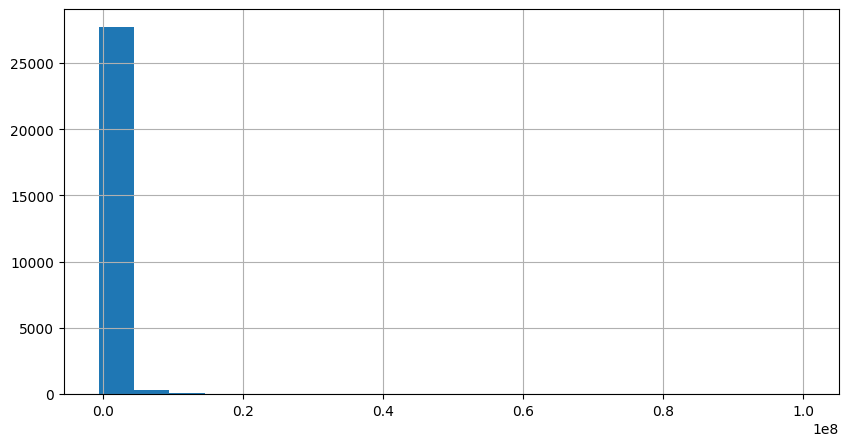

In [3]:
#Q2.2
df['Foreign Gift Amount'].hist(bins=20,figsize=(10,5))
df['Foreign Gift Amount'].describe()
#a majority of foreign gifts are small however a few are much larger bring the mean up despite the amount of smaller gifts.

In [4]:
#Q2.3 
print(df['Gift Type'].value_counts())
print(f'monetary gift proportion: {df["Gift Type"].value_counts()["Monetary Gift"] / df.shape[0]}')
print(f'contract gift proportion: {df["Gift Type"].value_counts()["Contract"] / df.shape[0]}')
print(f'real estate gift proportion: {df["Gift Type"].value_counts()["Real Estate"] / df.shape[0]}')

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
monetary gift proportion: 0.3875128450444704
contract gift proportion: 0.6120973742957372
real estate gift proportion: 0.00038978065979235324


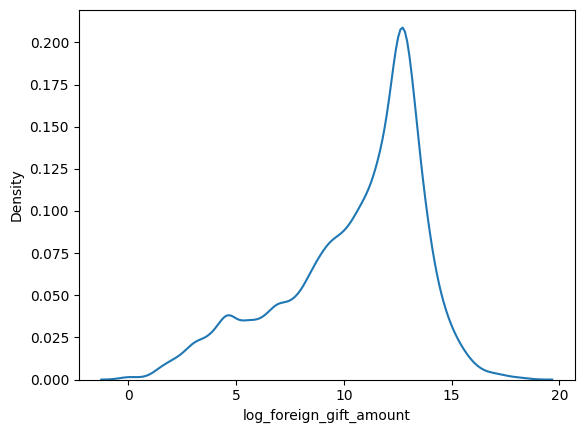

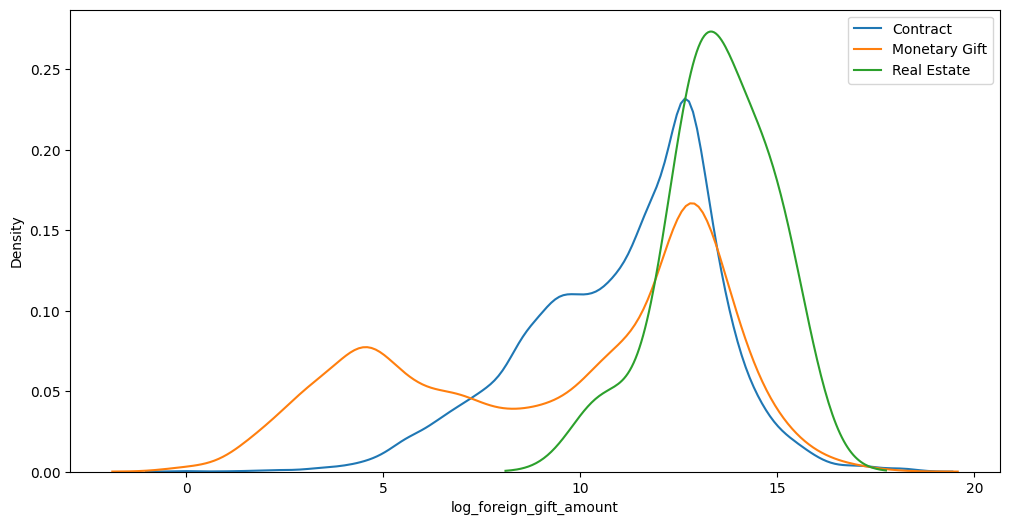

In [5]:
#Q2.4
positive_df = df.loc[df['Foreign Gift Amount'] > 0].copy()
positive_df['log_foreign_gift_amount'] = np.log(positive_df['Foreign Gift Amount'])

sns.kdeplot(data=positive_df, x='log_foreign_gift_amount')
plt.show()

plt.figure(figsize=(12, 6))
for gift_type, group in positive_df.groupby('Gift Type'):
    sns.kdeplot(data=group, x='log_foreign_gift_amount', label=gift_type, fill=False)

plt.legend()
plt.show()


In [6]:
#Q2.5
print(df['Foreign Gift Amount'].groupby(df['Country of Giftor']).count().sort_values(ascending=False).head(15))
print(df['Foreign Gift Amount'].groupby(df['Country of Giftor']).sum().sort_values(ascending=False).head(15))
#total count of gifts and total sum of gifts by country shown below.

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** db3a3ea80d1d65f79f013029116a3c269eaeaf03
- **AI tool and model used:** Chat-GPT GPT-5.6 Sol High

### *Prompts used

1. taking the following juypter notebook, suggest changes to the phase 1 section individually and as a summarized list, showing all suggested changes in accordance to the phase 2 guidelines


### *AI-proposed changes


1. Correct the Q1.1 proof so \(m(a+bX)=\frac1N\sum(a+bx_i)=a+b(\frac1N\sum x_i)=a+b\,m(X)\); the current handwritten work contains an extra \(x_i\) in the first expansion and temporarily loses the \(1/N\) factor.
2. Keep the Q1.2 argument but use \(y_i\) consistently inside the covariance summation and explicitly use \(m(a+bY)=a+b\,m(Y)\) before factoring out \(b\).
3. In Q1.3, use \(x_i\) consistently and explicitly show \(\operatorname{cov}(X,X)=\frac1N\sum(x_i-m(X))^2=s^2\), rather than only marking the expression with an arrow to \(s^2\).
4. Strengthen Q1.4 with a specific non-decreasing counterexample, such as \(g(x)=x^3\) and \(X=\{1,3\}\), for which \(m(g(X))=14\) but \(g(m(X))=8\).
5. In Q2.1, optionally print the dataframe shape, columns, and first rows to verify that the dataset loaded correctly and identify the donor-name column needed later.
6. In Q2.2, label the histogram and expand the interpretation: the distribution is strongly right-skewed, the mean is much larger than the median, the maximum is $100 million, and negative gift amounts are present.
7. In Q2.3, use value_counts(dropna=False) to check missing categories and value_counts(normalize=True) to calculate the gift-type proportions more directly, then state the percentages in prose.
8. In Q2.4, report how many non-positive gift amounts are excluded before taking logs, label the KDE plots, and add a written interpretation of the overall and gift-type-specific distributions; note that the Real Estate KDE is based on only 11 observations.
9. In Q2.5, use groupby('Country of Giftor').size() for the number of gifts, keep .sum() for total amounts, interpret the leading countries, and investigate inconsistent categories such as KOREA versus SOUTH KOREA before merging anything.
10. Add the currently missing Q2.6 by identifying the exact giftor-name column and grouping it by Foreign Gift Amount, summing and sorting descending to find which giftors provide the most money in total.
11. Put substantive interpretations in Markdown cells rather than code comments, then restart the kernel and run the complete Phase 2 solution from top to bottom to verify every reported value and plot.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |
| 3 | Accept / modify / reject | ... |
| 4 | Accept / modify / reject | ... |
| 5 | Accept / modify / reject | ... |
| 6 | Accept / modify / reject | ... |
| 7 | Accept / modify / reject | ... |
| 8 | Accept / modify / reject | ... |
| 9 | Accept / modify / reject | ... |
| 10 | Accept / modify / reject | ... |
| 11 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [7]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]